In [12]:
# ══════════════════════════════════════════════════════════════
# RANDOM FOREST — Student Dropout Prediction
# ══════════════════════════════════════════════════════════════
# Algorithm: Random Forest Classifier
# Dataset: OULAD — Open University Learning Analytics
# Author: U Kajanthan IT22224002
# ══════════════════════════════════════════════════════════════

# Import data handling libraries
import pandas as pd
import numpy as np

# Import Random Forest algorithm
from sklearn.ensemble import RandomForestClassifier

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [13]:
# ══════════════════════════════════════════════════════════════
# LOAD PREPROCESSED DATA
# ══════════════════════════════════════════════════════════════
# Data was prepared in 01_data_preprocessing.ipynb
# We load directly from data/processed/ folder

# Load training features and labels
X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()

# Load testing features and labels
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

# Confirm shapes
print("=== Data loaded successfully ===")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")
print()

# Confirm class balance in training set
print("=== Training set class distribution ===")
print(y_train.value_counts())
print()
print(f"Non-Dropout (0): {sum(y_train==0)}")
print(f"Dropout     (1): {sum(y_train==1)}")
print()

# Show feature names
print("=== Features used ===")
print(X_train.columns.tolist())
print()
print("Data loaded and ready for Random Forest!")

=== Data loaded successfully ===
X_train shape: (27532, 14)
X_test shape:  (6519, 14)
y_train shape: (27532,)
y_test shape:  (6519,)

=== Training set class distribution ===
dropout
1    13766
0    13766
Name: count, dtype: int64

Non-Dropout (0): 13766
Dropout     (1): 13766

=== Features used ===
['highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'total_clicks', 'days_active', 'avg_daily_clicks', 'avg_score', 'total_score', 'submission_count', 'min_score', 'max_score', 'withdrew_early']

Data loaded and ready for Random Forest!


In [14]:
# ══════════════════════════════════════════════════════════════
# TRAIN RANDOM FOREST MODEL
# ══════════════════════════════════════════════════════════════
# RandomForestClassifier builds 200 decision trees
# Each tree trains on a random subset of data and features
# Final prediction = majority vote across all 100 trees

print("Training Random Forest model...")
print()

rf_model = RandomForestClassifier(
    n_estimators=200,        # 200 trees — more stable than 100
    max_depth=10,            # limit depth — prevents overfitting
    min_samples_split=5,     # node needs 5 samples before splitting
    min_samples_leaf=2,      # each leaf needs minimum 2 samples
    max_features='sqrt',     # each tree sees sqrt(14)=4 random features
    random_state=42,         # same result every run
    n_jobs=-1                # use all CPU cores — faster training
)

# Train on SMOTE balanced training data
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")
print()
print(f"Number of trees:           {rf_model.n_estimators}")
print(f"Max depth per tree:        {rf_model.max_depth}")
print(f"Features per split:        {rf_model.max_features}")
print(f"Number of input features:  {rf_model.n_features_in_}")
print(f"Classes predicted:         {rf_model.classes_}")

Training Random Forest model...

Random Forest model trained successfully!

Number of trees:           200
Max depth per tree:        10
Features per split:        sqrt
Number of input features:  14
Classes predicted:         [0 1]


In [15]:
# ══════════════════════════════════════════════════════════════
# PREDICTIONS AND EVALUATION METRICS
# ══════════════════════════════════════════════════════════════
# Model predicts on unseen test data (6,519 students)
# Test data was never seen during training — fair evaluation

print("Making predictions on test data...")
print()

# Make predictions on test set
y_pred = rf_model.predict(X_test)

# Predict probabilities — needed for ROC-AUC score
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("=== MODEL EVALUATION RESULTS ===")
print()

# Calculate all metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_pred_proba)

# Print all metrics clearly
print(f"Accuracy:  {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall:    {recall*100:.2f}%")
print(f"F1 Score:  {f1*100:.2f}%")
print(f"ROC-AUC:   {roc_auc*100:.2f}%")
print()

# Full classification report
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred,
      target_names=['Non-Dropout (0)', 'Dropout (1)']))

Making predictions on test data...

=== MODEL EVALUATION RESULTS ===

Accuracy:  89.32%
Precision: 92.12%
Recall:    87.25%
F1 Score:  89.62%
ROC-AUC:   96.43%

=== CLASSIFICATION REPORT ===
                 precision    recall  f1-score   support

Non-Dropout (0)       0.87      0.92      0.89      3077
    Dropout (1)       0.92      0.87      0.90      3442

       accuracy                           0.89      6519
      macro avg       0.89      0.89      0.89      6519
   weighted avg       0.89      0.89      0.89      6519



In [ ]:
# ══════════════════════════════════════════════════════════════
# OVERFITTING CHECK
# ══════════════════════════════════════════════════════════════
# Compare training accuracy vs test accuracy


train_accuracy = rf_model.score(X_train, y_train)
test_accuracy  = rf_model.score(X_test, y_test)
gap            = (train_accuracy - test_accuracy) * 100

print(f"Train accuracy: {train_accuracy*100:.2f}%")
print(f"Test accuracy:  {test_accuracy*100:.2f}%")
print(f"Gap:            {gap:.2f}%")
print()

if gap < 5:
    print("No overfitting")
elif gap < 10:
    print("Mild overfitting")
else:
    print("Overfitting detected")

Train accuracy: 91.74%
Test accuracy:  89.32%
Gap:            2.42%

No overfitting


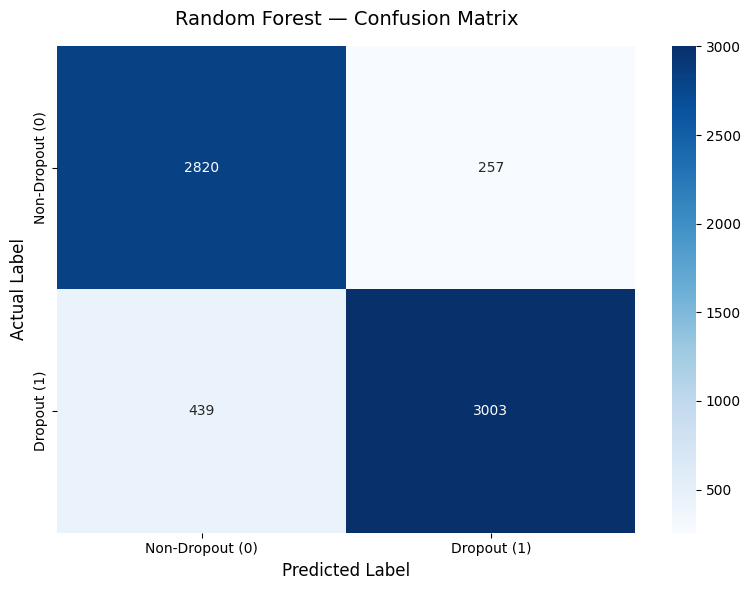

True Negatives  (correctly predicted Non-Dropout): 2820
False Positives (predicted Dropout, actually Not): 257
False Negatives (predicted Not, actually Dropout): 439
True Positives  (correctly predicted Dropout):     3003

Total correct predictions:   5823
Total incorrect predictions: 696
Chart saved to report folder


In [17]:
# ══════════════════════════════════════════════════════════════
# CONFUSION MATRIX
# ══════════════════════════════════════════════════════════════
# Shows 4 values:
# True Positive  (TP) — predicted dropout,     actually dropout     
# True Negative  (TN) — predicted non-dropout, actually non-dropout 
# False Positive (FP) — predicted dropout,     actually non-dropout 
# False Negative (FN) — predicted non-dropout, actually dropout     

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Dropout (0)', 'Dropout (1)'],
    yticklabels=['Non-Dropout (0)', 'Dropout (1)']
)
plt.title('Random Forest — Confusion Matrix', fontsize=14, pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.tight_layout()
plt.savefig('../report/04_rf_confusion_matrix.png', dpi=150)
plt.show()

# Print confusion matrix values clearly
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly predicted Non-Dropout): {tn}")
print(f"False Positives (predicted Dropout, actually Not): {fp}")
print(f"False Negatives (predicted Not, actually Dropout): {fn}")
print(f"True Positives  (correctly predicted Dropout):     {tp}")
print()
print(f"Total correct predictions:   {tn+tp}")
print(f"Total incorrect predictions: {fp+fn}")
print(f"Chart saved to report folder")

=== Feature Importance Rankings ===
             feature  importance
         total_score    0.250060
      withdrew_early    0.210893
    submission_count    0.196346
           max_score    0.078132
         days_active    0.066955
           avg_score    0.064768
        total_clicks    0.049639
           min_score    0.043798
    avg_daily_clicks    0.015537
     studied_credits    0.006847
num_of_prev_attempts    0.006138
            imd_band    0.004965
   highest_education    0.004677
            age_band    0.001245



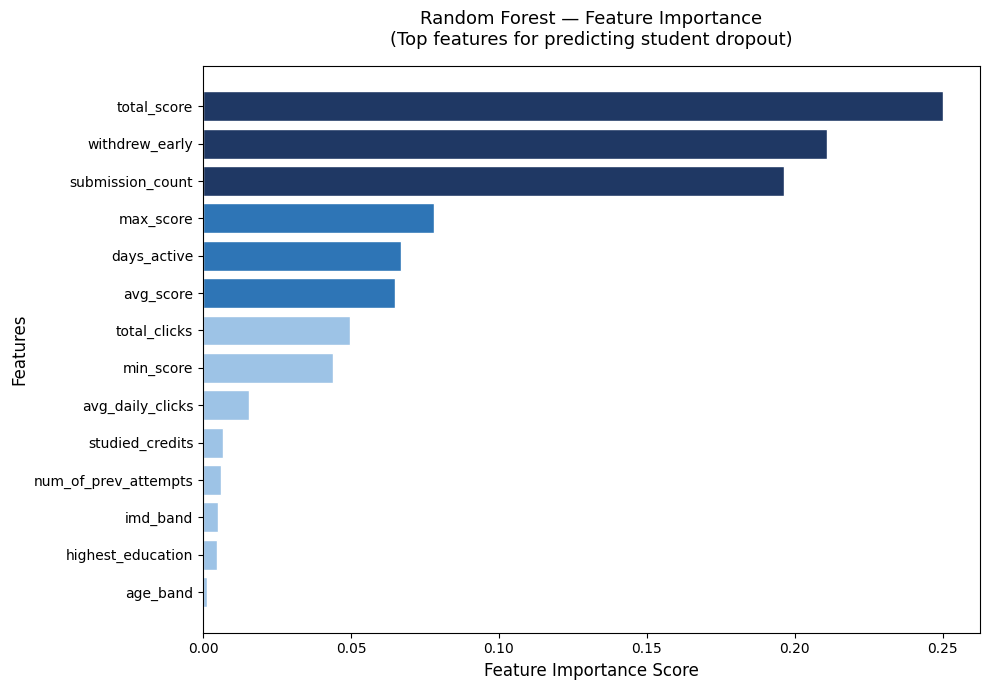

Feature importance chart saved to report folder!


In [18]:
# ══════════════════════════════════════════════════════════════
# FEATURE IMPORTANCE
# ══════════════════════════════════════════════════════════════
# Random Forest calculates how much each feature
# reduces impurity across all 200 trees
# Higher value = more important for dropout prediction

# Get feature importance scores
feature_importance = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("=== Feature Importance Rankings ===")
print(feature_importance.to_string(index=False))
print()

# Plot feature importance
plt.figure(figsize=(10, 7))
colors = ['#1F3864' if i < 3 else '#2E75B6' if i < 6 else '#9DC3E6'
          for i in range(len(feature_importance))]

plt.barh(
    feature_importance['feature'],
    feature_importance['importance'],
    color=colors,
    edgecolor='white'
)
plt.xlabel('Feature Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Random Forest — Feature Importance\n(Top features for predicting student dropout)',
          fontsize=13, pad=15)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../report/05_rf_feature_importance.png', dpi=150)
plt.show()

print("Feature importance chart saved to report folder!")